In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
dataB11 = pd.read_csv("FORGE 16B(78)-32 BHA11.csv", skiprows=37)
dataB12 = pd.read_csv("FORGE 16B(78)-32 BHA12.csv", skiprows=37)
dataB13 = pd.read_csv("FORGE 16B(78)-32 BHA13.csv", skiprows=37)
dataB14 = pd.read_csv("FORGE 16B(78)-32 BHA14.csv", skiprows=37)
dataB15 = pd.read_csv("FORGE 16B(78)-32 BHA15.csv", skiprows=37)
dataB16 = pd.read_csv("FORGE 16B(78)-32 BHA16.csv", skiprows=37)
dataB17 = pd.read_csv("FORGE 16B(78)-32 BHA17.csv", skiprows=37)

In [40]:
print("Data B11 columns:", dataB11.columns)
print("Data B12 columns:", dataB12.columns)   
print("Data B13 columns:", dataB13.columns)
print("Data B14 columns:", dataB14.columns)
print("Data B15 columns:", dataB15.columns)
print("Data B16 columns:", dataB16.columns)
print("Data B17 columns:", dataB17.columns)

Data B11 columns: Index(['DateTime', 'SN5105_GyroXmax(RPM)', 'SN5105_GyroXmin(RPM)',
       'SN5105_GyroXmed(RPM)', 'SN5105_GyroXspread(RPM)',
       'SN5105_StickSlip(%)', 'SN5105_Temperature(C)', 'SN5105_ShXpeak(g)',
       'SN5105_ShXrms(g)', 'SN5105_ShXmax(g)', 'SN5105_ShYpeak(g)',
       'SN5105_ShYrms(g)', 'SN5105_ShYmax(g)', 'SN5105_ShZpeak(g)',
       'SN5105_ShZrms(g)', 'SN5105_ShZmax(g)', 'Hole Depth(ft)', 'TVD(ft)',
       'Surface_Top Drive RPM(RPM)', 'Block Height(ft)',
       'Surface_Flow In(GPM)', 'Torque(kft-lbf)',
       'Surface_Weight on Bit(klbs)', 'Standpipe Pressure(psi)',
       'Differential Pressure(psi)', 'Rate of Penetration(ft/hr)',
       'Gamma(API)', 'Rate of Penetration SP(ft/hr)'],
      dtype='object')
Data B12 columns: Index(['DateTime', 'SN5104_GyroXmax(RPM)', 'SN5104_GyroXmin(RPM)',
       'SN5104_GyroXmed(RPM)', 'SN5104_GyroXspread(RPM)',
       'SN5104_StickSlip(%)', 'SN5104_Temperature(C)', 'SN5104_ShXpeak(g)',
       'SN5104_ShXrms(g)', 'SN5104

In [41]:
dataB11.rename(columns={'SN5105_ShYmax(g)': 'Bit Box_ShYpeak(g)',
                      'SN5105_ShZmax(g)': 'Bit Box_ShZpeak(g)',
                      'SN5105_ShXmax(g)': 'Bit Box_ShXpeak(g)'}, inplace=True)
dataB12.rename(columns={'SN5104_ShYmax(g)': 'Bit Box_ShYpeak(g)',
                      'SN5104_ShZmax(g)': 'Bit Box_ShZpeak(g)',
                      'SN5104_ShXmax(g)': 'Bit Box_ShXpeak(g)'}, inplace=True)
dataB13.rename(columns={'SN5104_ShYmax(g)': 'Bit Box_ShYpeak(g)',
                      'SN5104_ShZmax(g)': 'Bit Box_ShZpeak(g)',
                      'SN5104_ShXmax(g)': 'Bit Box_ShXpeak(g)'}, inplace=True)
dataB14.rename(columns={'SN2232_ShYmax(g)': 'Bit Box_ShYpeak(g)',
                      'SN2232_ShZmax(g)': 'Bit Box_ShZpeak(g)',
                      'SN2232_ShXmax(g)': 'Bit Box_ShXpeak(g)'}, inplace=True)
dataB15.rename(columns={'SN2232_ShYmax(g)': 'Bit Box_ShYpeak(g)',
                      'SN2232_ShZmax(g)': 'Bit Box_ShZpeak(g)',
                      'SN2232_ShXmax(g)': 'Bit Box_ShXpeak(g)'}, inplace=True)
dataB16.rename(columns={'SN2232_ShYmax(g)': 'Bit Box_ShYpeak(g)',
                      'SN2232_ShZmax(g)': 'Bit Box_ShZpeak(g)',
                      'SN2232_ShXmax(g)': 'Bit Box_ShXpeak(g)'}, inplace=True)
dataB17.rename(columns={'SN2232_ShYmax(g)': 'Bit Box_ShYpeak(g)',
                      'SN2232_ShZmax(g)': 'Bit Box_ShZpeak(g)',
                      'SN2232_ShXmax(g)': 'Bit Box_ShXpeak(g)'}, inplace=True)

In [42]:
dataB11["Augmented RPM(RPM)"] = np.where(
    dataB11["Surface_Top Drive RPM(RPM)"] >= 0.1,
    dataB11["Surface_Flow In(GPM)"] * 0.242 + dataB11["Surface_Top Drive RPM(RPM)"],
    dataB11["Surface_Flow In(GPM)"] * 0.242
)
dataB17["Augmented RPM(RPM)"] = np.where(
    dataB17["Surface_Top Drive RPM(RPM)"] >= 0.1,
    dataB17["Surface_Flow In(GPM)"] * 0.242 + dataB17["Surface_Top Drive RPM(RPM)"],
    dataB17["Surface_Flow In(GPM)"] * 0.242
)
dataB12["Augmented RPM(RPM)"] = dataB12["Surface_Top Drive RPM(RPM)"]
dataB13["Augmented RPM(RPM)"] = dataB13["Surface_Top Drive RPM(RPM)"]
dataB14["Augmented RPM(RPM)"] = dataB14["Surface_Top Drive RPM(RPM)"]
dataB15["Augmented RPM(RPM)"] = dataB15["Surface_Top Drive RPM(RPM)"]
dataB16["Augmented RPM(RPM)"] = dataB16["Surface_Top Drive RPM(RPM)"]
dataB17["Augmented RPM(RPM)"] = dataB17["Surface_Top Drive RPM(RPM)"]

dataB11 = dataB11[(dataB11["Augmented RPM(RPM)"] < 250) & (dataB11["Augmented RPM(RPM)"] > 10)]

In [43]:
dataBB = pd.concat([dataB11.copy(), dataB12.copy(), dataB13.copy()])
dataBR = pd.concat([dataB14.copy(), dataB15.copy(), dataB16.copy(), dataB17.copy()])

0.0 249.97325999999998


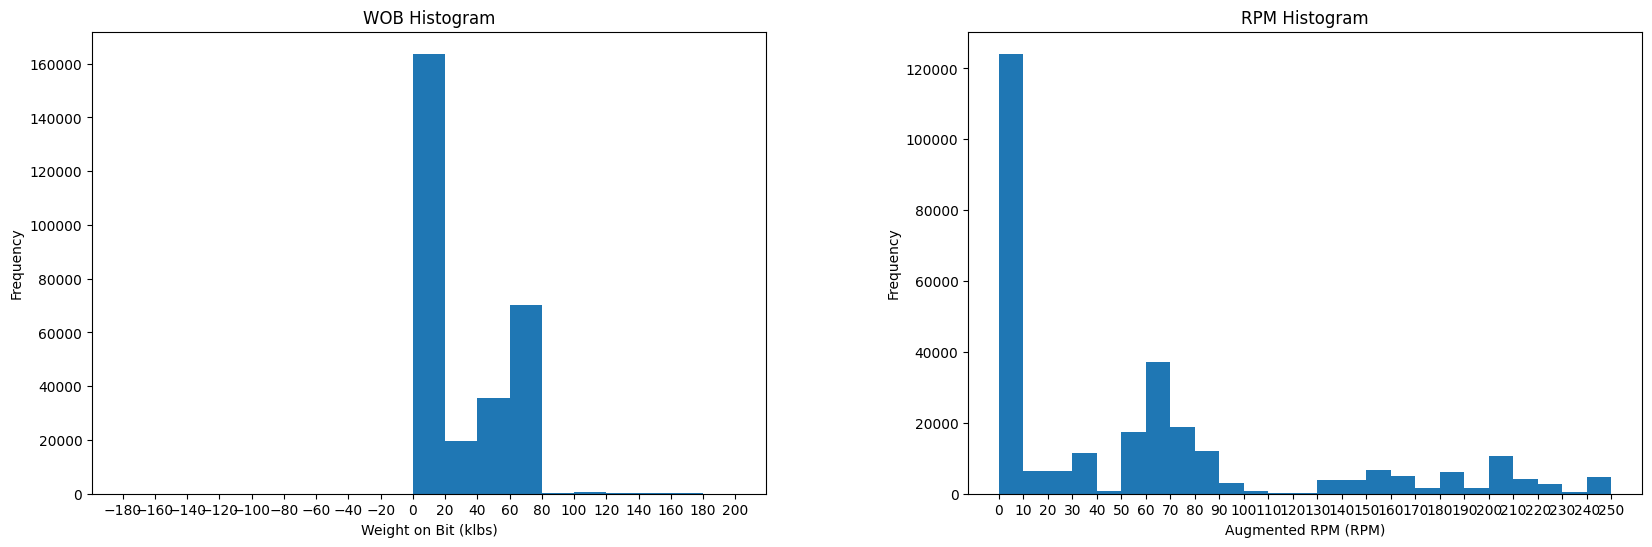

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Create figure with ONLY 2 subplots
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

# --------------------------------------------------
# WOB Histogram
# --------------------------------------------------
WOB = dataBB["Surface_Weight on Bit(klbs)"].dropna()

min_wob = WOB.min()
max_wob = WOB.max()
binsWOB = np.arange(-180, max_wob + 20, 20)

axes[0].hist(WOB, bins=binsWOB)
axes[0].set_xlabel("Weight on Bit (klbs)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("WOB Histogram")
axes[0].set_xticks(binsWOB)

# --------------------------------------------------
# RPM Histogram
# --------------------------------------------------
RPM = dataBB["Augmented RPM(RPM)"].dropna()

min_RPM = RPM.min()
max_RPM = RPM.max()
print(min_RPM, max_RPM)
binsRPM = np.arange(0, max_RPM + 10, 10)

axes[1].hist(RPM, bins=binsRPM)
axes[1].set_xlabel("Augmented RPM (RPM)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("RPM Histogram")
axes[1].set_xticks(binsRPM)

plt.show()


0.0 155.85


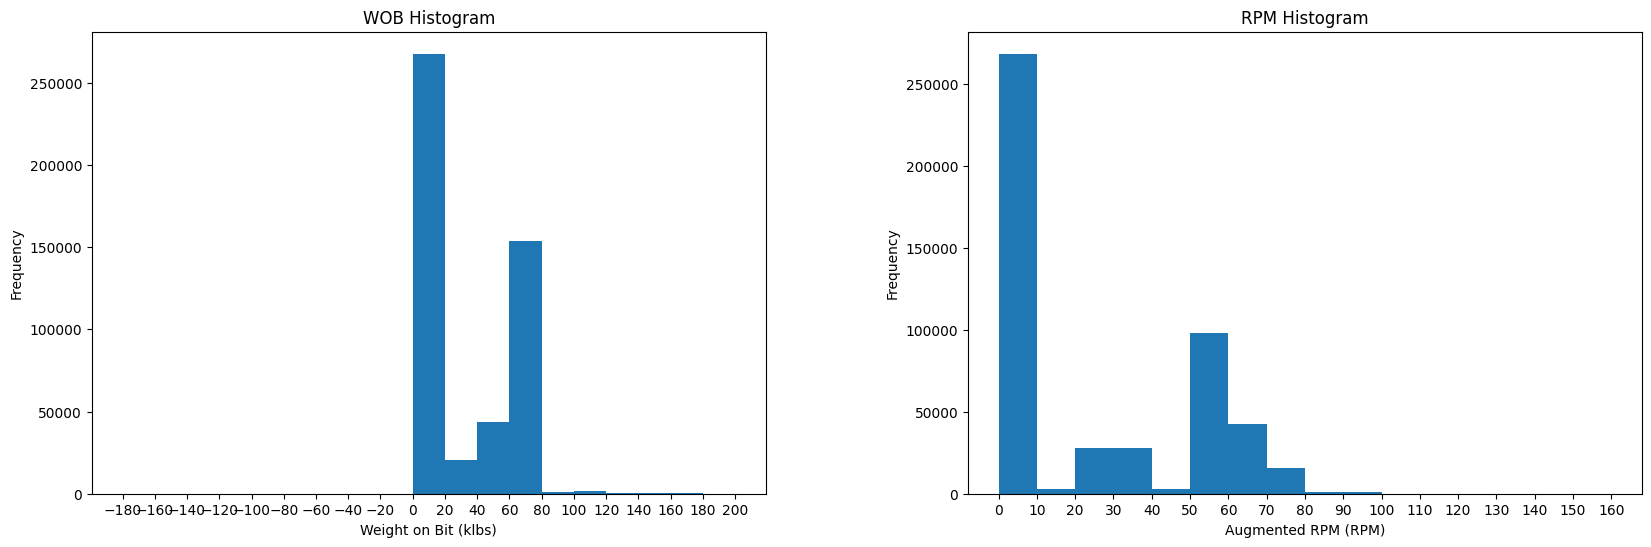

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Create figure with ONLY 2 subplots
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.subplots_adjust(wspace=0.3)

# --------------------------------------------------
# WOB Histogram
# --------------------------------------------------
WOB = dataBR["Surface_Weight on Bit(klbs)"].dropna()

min_wob = WOB.min()
max_wob = WOB.max()
binsWOB = np.arange(-180, max_wob + 20, 20)

axes[0].hist(WOB, bins=binsWOB)
axes[0].set_xlabel("Weight on Bit (klbs)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("WOB Histogram")
axes[0].set_xticks(binsWOB)

# --------------------------------------------------
# RPM Histogram
# --------------------------------------------------
RPM = dataBR["Augmented RPM(RPM)"].dropna()

min_RPM = RPM.min()
max_RPM = RPM.max()
print(min_RPM, max_RPM)
binsRPM = np.arange(0, max_RPM + 10, 10)

axes[1].hist(RPM, bins=binsRPM)
axes[1].set_xlabel("Augmented RPM (RPM)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("RPM Histogram")
axes[1].set_xticks(binsRPM)

plt.show()

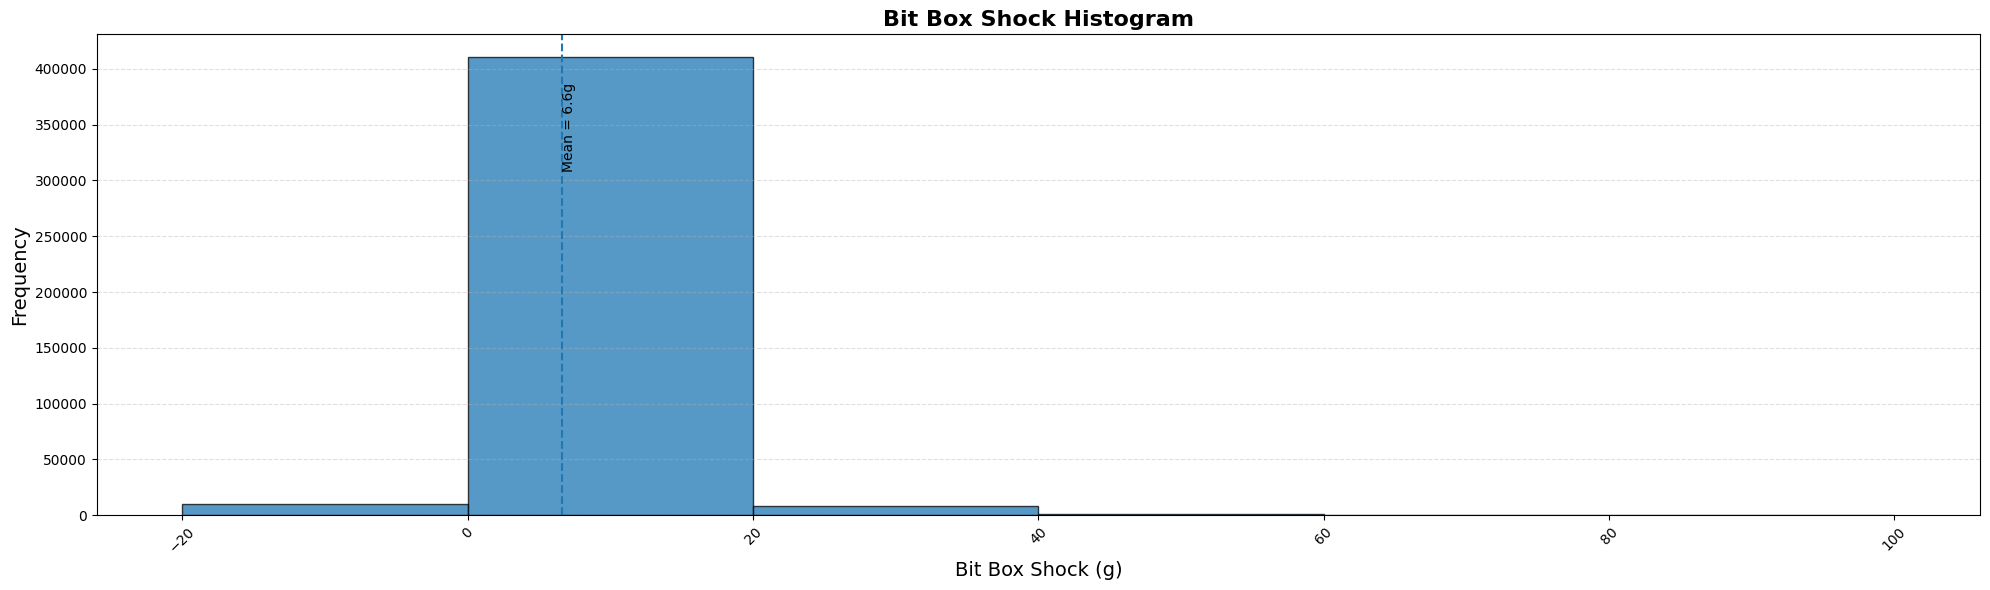

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Create figure (single axis)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 6))

# --------------------------------------------------
# Data
# --------------------------------------------------
WOB = dataBR["Bit Box_ShYpeak(g)"].dropna()

min_wob = WOB.min()
max_wob = WOB.max()

# Use cleaner bin spacing
bin_width = 20
binsWOB = np.arange(np.floor(min_wob / bin_width) * bin_width,
                    np.ceil(max_wob / bin_width) * bin_width + bin_width,
                    bin_width)

# --------------------------------------------------
# Plot Histogram
# --------------------------------------------------
ax.hist(WOB, bins=binsWOB, edgecolor='black', alpha=0.75)

# Labels & title
ax.set_xlabel("Bit Box Shock (g)", fontsize=14)
ax.set_ylabel("Frequency", fontsize=14)
ax.set_title("Bit Box Shock Histogram", fontsize=16, fontweight='bold')

# Clean ticks
ax.set_xticks(binsWOB)
ax.tick_params(axis='x', rotation=45)

# Add grid
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Add mean line
mean_val = WOB.mean()
ax.axvline(mean_val, linestyle='--')
ax.text(mean_val, ax.get_ylim()[1]*0.9,
        f"Mean = {mean_val:.1f}g",
        rotation=90,
        verticalalignment='top')

plt.tight_layout()
plt.show()